# Task 7 - Explainable AI Analysis

## 7.1 Import SHAP

SHAP is used to explain the Logistic Regression model because Task 6 identified it as the best-performing model overall, with the highest test macro-F1 score. Since Logistic Regression is a linear model, no proxy model is needed. This also allows SHAP to use the LinearExplainer, which provides fast and exact explanations for the model.

In [ ]:
!pip install shap -q
import shap
shap.initjs()

## 7.2 Build Explainer and Compute SHAP Values

In [ ]:
# Logistic Regression was trained on SCALED features (Task 05) and is the best model (Task 06)
explain_model = models['Logistic Regression']

X_train_scaled_numeric = X_train_scaled.astype(float)
X_test_scaled_numeric = X_test_scaled.astype(float)
X_train_array = X_train_scaled_numeric.to_numpy(dtype='float64')
X_test_array = X_test_scaled_numeric.to_numpy(dtype='float64')

background = shap.sample(X_train_array, 100, random_state=RANDOM_STATE)
explainer = shap.LinearExplainer(explain_model, background)
shap_values = explainer.shap_values(X_test_array)

class_labels = CLASS_LABELS
print("Classes:", class_labels)

Classes: ['Low', 'Medium', 'High']


## 7.3 Global Explanation – Summary Plot

The beeswarm plot below shows which features have the most influence on predictions of 'High' disease risk and whether they increase or decrease the prediction.

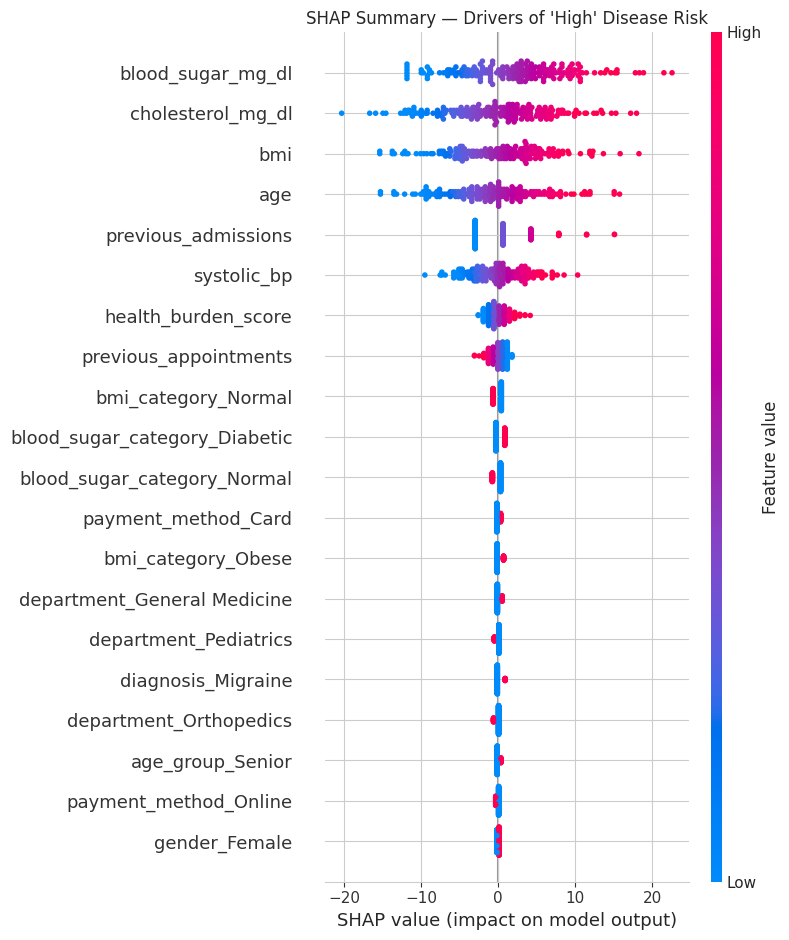

In [ ]:
high_idx = class_labels.index('High')

X_test_scaled_numeric = X_test_scaled.astype(float)
X_test_array = X_test_scaled_numeric.to_numpy(dtype='float64')

plt.figure()
shap.summary_plot(
    shap_values[:, :, high_idx],
    X_test_array,
    feature_names=X_test_scaled_numeric.columns.tolist(),
    show=False
)
plt.title("SHAP Summary — Drivers of 'High' Disease Risk")
plt.tight_layout()
plt.show()

## 7.4 Global Explanation – Feature Importance Across Classes

This bar chart shows the average feature importance for all three risk classes.


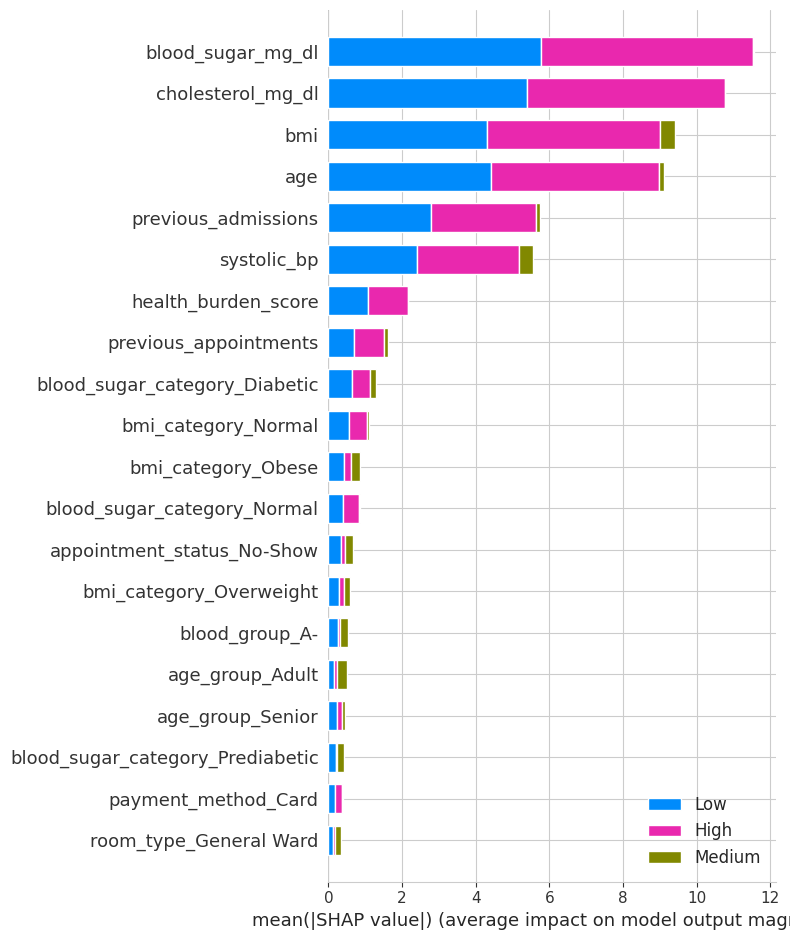

In [ ]:
plt.figure()
shap.summary_plot(shap_values, X_test_scaled_numeric, feature_names=X_test_scaled_numeric.columns, class_names=class_labels, plot_type="bar", show=False)
plt.tight_layout()
plt.show()

## 7.5 Local Explanations - Individual Predictions

The waterfall plots below explain individual predictions: one correctly predicted High-risk patient, one correctly predicted Low-risk patient, and one misclassified case.


Correctly predicted High — predicted: High, actual: High


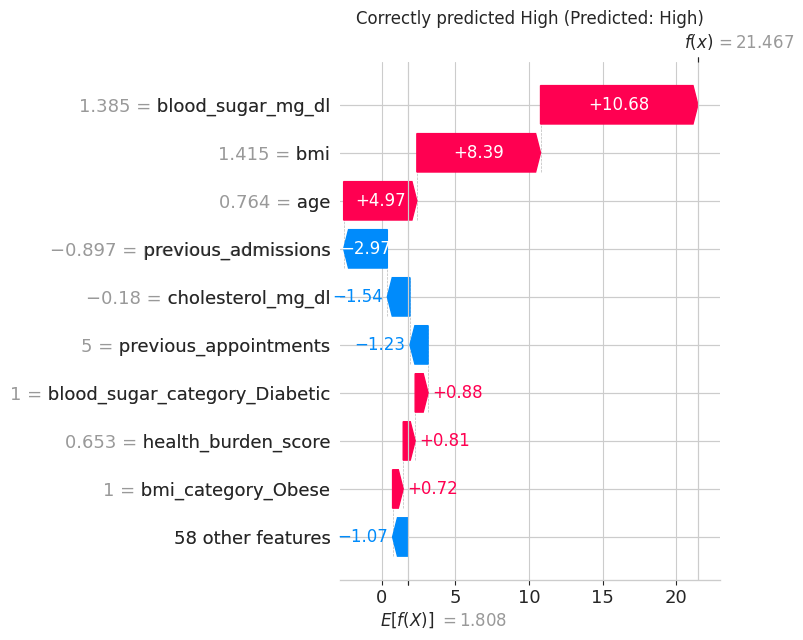


Correctly predicted Low — predicted: Low, actual: Low


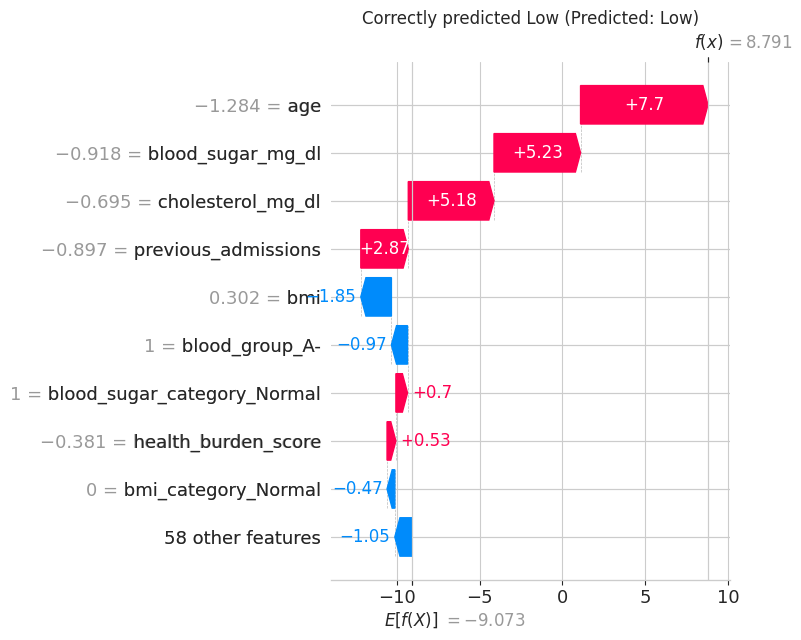


Misclassified case — predicted: High, actual: Medium


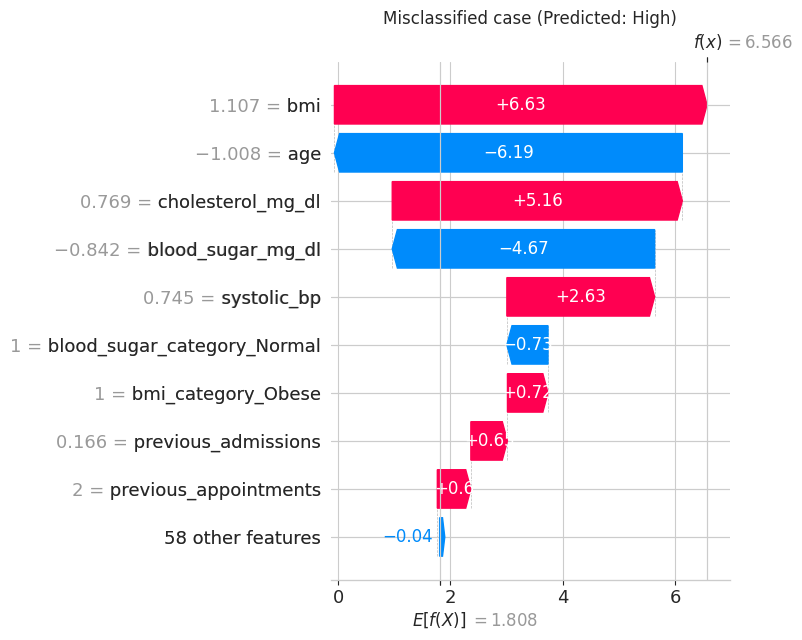

In [ ]:
y_pred_lr = predictions['Logistic Regression']
y_test_arr = y_test.values if hasattr(y_test, 'values') else y_test

correct_high_idx = np.where((y_test_arr == class_labels.index('High')) & (y_pred_lr == class_labels.index('High')))[0][0]
correct_low_idx  = np.where((y_test_arr == class_labels.index('Low'))  & (y_pred_lr == class_labels.index('Low')))[0][0]
misclassified = np.where(y_test_arr != y_pred_lr)[0]
wrong_idx = misclassified[0] if len(misclassified) else correct_high_idx

for label, idx in [("Correctly predicted High", correct_high_idx),
                    ("Correctly predicted Low", correct_low_idx),
                    ("Misclassified case", wrong_idx)]:
    predicted_class = y_pred_lr[idx]
    print(f"\n{label} — predicted: {class_labels[predicted_class]}, actual: {class_labels[y_test_arr[idx]]}")
    explanation = shap.Explanation(
        values=shap_values[idx, :, predicted_class],
        base_values=explainer.expected_value[predicted_class],
        data=X_test_scaled_numeric.iloc[idx],
        feature_names=X_test_scaled_numeric.columns.tolist()
    )
    plt.figure()
    shap.plots.waterfall(explanation, show=False)
    plt.title(f"{label} (Predicted: {class_labels[predicted_class]})")
    plt.tight_layout()
    plt.show()

## 7.6 SHAP Dependence Plots - Feature Interaction Effects

<Figure size 800x500 with 0 Axes>

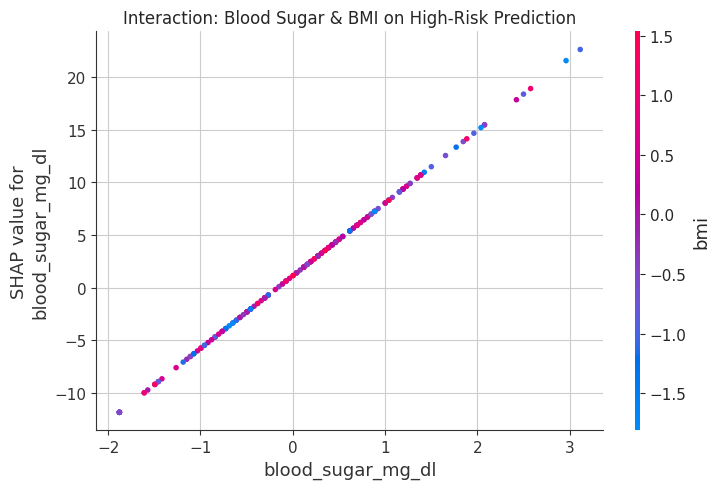

<Figure size 800x500 with 0 Axes>

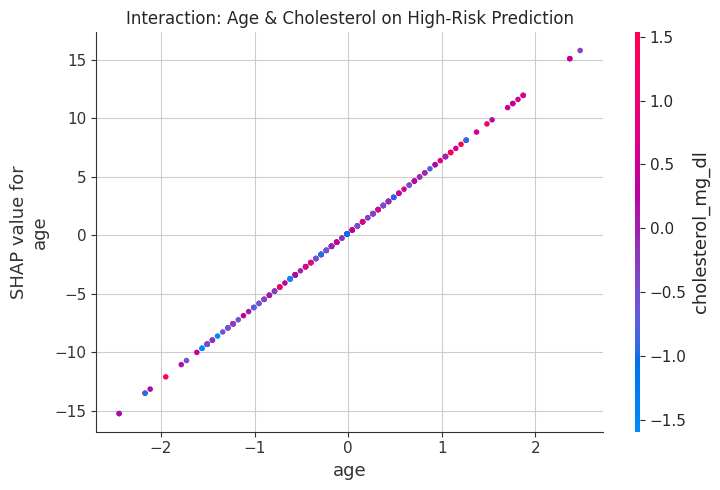

In [ ]:
high_idx = class_labels.index('High')

plt.figure()
shap.dependence_plot(
    "blood_sugar_mg_dl", shap_values[:, :, high_idx], X_test_scaled_numeric,
    feature_names=X_test_scaled_numeric.columns.tolist(), interaction_index="bmi", show=False
)
plt.title("Interaction: Blood Sugar & BMI on High-Risk Prediction")
plt.tight_layout()
plt.show()

plt.figure()
shap.dependence_plot(
    "age", shap_values[:, :, high_idx], X_test_scaled_numeric,
    feature_names=X_test_scaled_numeric.columns.tolist(), interaction_index="cholesterol_mg_dl", show=False
)
plt.title("Interaction: Age & Cholesterol on High-Risk Prediction")
plt.tight_layout()
plt.show()

## 7.7 LIME - Cross-Validation of SHAP Explanations

In [ ]:
!pip install lime -q
from lime.lime_tabular import LimeTabularExplainer

lime_explainer = LimeTabularExplainer(
    training_data=X_train_scaled_numeric.values,
    feature_names=X_train_scaled_numeric.columns.tolist(),
    class_names=class_labels,
    mode='classification',
    random_state=RANDOM_STATE
)

lime_exp = lime_explainer.explain_instance(
    X_test_scaled_numeric.iloc[wrong_idx].values,
    explain_model.predict_proba,
    num_features=10,
    top_labels=1
)
lime_exp.show_in_notebook(show_table=True)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


## Interpretation and Ethical Implications

For this misclassified case (true: Medium, predicted: High), SHAP and LIME show very similar results. Both identify bmi, age, cholesterol_mg_dl, blood_sugar_mg_dl, and systolic_bp as the main features affecting the prediction. Higher BMI, cholesterol, and blood pressure push the prediction toward High, while the patient's lower age and blood sugar support a lower risk class. LIME also shows a moderate confidence of 67% High and 33% Medium, which suggests that this was a borderline case rather than a confident error. Overall, both methods show that clinical vitals have more influence than operational or billing features. The SHAP dependence plots also show mostly linear relationships, which is consistent with the Logistic Regression model.

# Task 08 - AI Prototype Development



## 8.1 Save the model artifacts

In [ ]:
import joblib

# best_model = Logistic Regression (Task 06), trained on X_train_scaled (Task 05)
joblib.dump(best_model, 'disease_risk_model.pkl')

# scaler was fit in Task 03 on a specific 8-column subset only — save it as-is
joblib.dump(scaler, 'scaler.pkl')

# No LabelEncoder dict exists — Task 03 used one-hot encoding (pd.get_dummies).
# Save each nominal column's category set so the prototype can rebuild the same dummy columns for new patient input.
nominal_cols = ['gender', 'blood_group', 'department', 'diagnosis', 'room_type',
                 'payment_method', 'payment_status', 'appointment_status',
                 'bp_category', 'bmi_category', 'blood_sugar_category', 'age_group']
category_values = {col: sorted(df[col].dropna().unique().tolist()) for col in nominal_cols}
joblib.dump(category_values, 'category_values.pkl')

# No target_encoder object exists — Task 03 used a manual ordinal map instead
risk_order = {'Low': 0, 'Medium': 1, 'High': 2}
joblib.dump(risk_order, 'target_encoding.pkl')

# Exact feature columns/order the model expects — cast to match the dtype-clean float format used for SHAP in Task 7, so the prototype builds input consistently
X_train_scaled_numeric = X_train_scaled.astype(float)
joblib.dump(X_train_scaled_numeric.columns.tolist(), 'feature_columns.pkl')

# Numeric columns the scaler transforms — everything else (one-hot columns) passes through unscaled
joblib.dump(numeric_cols_to_scale, 'numeric_cols_to_scale.pkl')

!cp disease_risk_model.pkl scaler.pkl category_values.pkl target_encoding.pkl feature_columns.pkl numeric_cols_to_scale.pkl /content/drive/MyDrive/SmartCare/